In [43]:
import numpy as np
import time
from tqdm import tqdm
import matplotlib.pyplot as plt  # For visualizing input/reconstruction
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.optim as optim
#from pytorch_msssim import ms_ssim
from utils import ms_ssim
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from scipy.stats import norm, entropy
import random
import os
import math
from torchinfo import summary

In [ ]:
class VAE_MP4(nn.Module):
    def __init__(self, img_channels=2, latent_dim=2, img_size=140):
        super(VAE_MP4, self).__init__()

        # Calculate final feature map size after downsampling (140 → 8)
        self.final_size = img_size // 16  # 140 → 70 → 35 → 17 → 8
        self.flat_dim = 256 * self.final_size * self.final_size  # 256 * 8 * 8

        # ---------------------
        # Encoder: 4 Blocks with MaxPooling
        # ---------------------
        self.encoder = nn.Sequential(
            # Block 1: 140x140 → 70x70
            nn.Conv2d(img_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  

            # Block 2: 70x70 → 35x35
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  

            # Block 3: 35x35 → 17x17
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  

            # Block 4: 17x17 → 8x8
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  
        )

        # ---------------------
        # Latent Space
        # ---------------------
        self.fc_mu = nn.Linear(self.flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_dim, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, self.flat_dim)
        
        # More active units!!!
        #self.fc_mu = nn.Linear(self.flat_dim, latent_dim * 2)  # Increase capacity
        #self.fc_logvar = nn.Linear(self.flat_dim, latent_dim * 2)
        #self.fc_decode = nn.Linear(latent_dim * 2, self.flat_dim)

        # ---------------------
        # Decoder: 4 Blocks (using ConvTranspose2d)
        # ---------------------
        self.decoder = nn.Sequential(
            # Block 1: Upsample from 8x8 → 17x17
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            # Block 2: Upsample from 17x17 → 35x35
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            # Block 3: Upsample from 35x35 → 70x70
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            # Block 4: Upsample from 70x70 → 128x128
            nn.ConvTranspose2d(32, img_channels, kernel_size=4, stride=2, padding=1, output_padding=1),
            nn.ReLU()
        )

        # Final Upsample to **force output to 140x140**
        self.final_upsample = nn.Upsample(size=(img_size, img_size), mode='bilinear', align_corners=True)

    def encode(self, x):
        """Encode the input image into latent parameters (mu, logvar)."""
        h = self.encoder(x)  # (batch, 256, 8, 8)
        h_flat = h.view(-1, self.flat_dim)  # Flatten to (batch, 256 * 8 * 8)
        mu = self.fc_mu(h_flat)
        logvar = self.fc_logvar(h_flat)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """Sample from the latent distribution using the reparameterization trick."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        """Decode the latent vector z back to an image."""
        h_flat = self.fc_decode(z)  # (batch, 256 * 8 * 8)
        h = h_flat.view(-1, 256, self.final_size, self.final_size)  # Reshape to (batch, 256, 8, 8)
        x_recon = self.decoder(h)  # Upsample to (~128, ~128)
        x_recon = self.final_upsample(x_recon)  # 🔹 Ensure exactly (batch, 2, 140, 140)
        return x_recon

    def forward(self, x):
        """Forward pass: encode → reparameterize → decode."""
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

In [ ]:
class VAE_MP2_64(nn.Module):
    def __init__(self, img_channels=1, latent_dim=2, img_size=20):
        super(VAE_MP2_64, self).__init__()
        
        # Final feature map size after 2 downsampling steps: 20 → 10 → 5
        self.final_size = img_size // 4  # 20 // 4 = 5
        self.flat_dim = 64 * self.final_size * self.final_size  # 64 * 5 * 5 = 1600

        # ---------------------
        # Encoder: 2 Blocks (Conv → ReLU → MaxPool)
        # ---------------------
        self.encoder = nn.Sequential(
            # Block 1: 20x20 → 10x10
            nn.Conv2d(img_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2: 10x10 → 5x5
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # ---------------------
        # Latent Space
        # ---------------------
        self.fc_mu = nn.Linear(self.flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_dim, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, self.flat_dim)

        # ---------------------
        # Decoder: 2 Blocks (ConvTranspose → ReLU), then Final Upsample
        # ---------------------
        self.decoder = nn.Sequential(
            # Block 1: Upsample 5x5 → 10x10
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1, output_padding=0),
            nn.ReLU(),

            # Block 2: Upsample 10x10 → 20x20
            nn.ConvTranspose2d(32, img_channels, kernel_size=4, stride=2, padding=1, output_padding=0),
            nn.ReLU()  # Matches original MP4 final activation (then upsample)
        )

        # Final Upsample to ensure exactly (batch, 1, 20, 20)
        self.final_upsample = nn.Upsample(size=(img_size, img_size), mode='bilinear', align_corners=True)

    def encode(self, x):
        """Encode the input into latent parameters (mu, logvar)."""
        h = self.encoder(x)  # (batch, 64, 5, 5)
        h_flat = h.view(-1, self.flat_dim)  # (batch, 1600)
        mu = self.fc_mu(h_flat)
        logvar = self.fc_logvar(h_flat)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """Reparameterization trick to sample z."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        """Decode latent vector z back to an image."""
        h_flat = self.fc_decode(z)  # (batch, 1600)
        h = h_flat.view(-1, 64, self.final_size, self.final_size)  # (batch, 64, 5, 5)
        x_recon = self.decoder(h)  # ~ (batch, 1, 20, 20)
        x_recon = self.final_upsample(x_recon)  # Force exact 20x20 if there's any offset
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar


## Seeding

In [9]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)  # If you're using GPU
    torch.cuda.manual_seed_all(seed)  # If you use multi-GPU
    torch.backends.cudnn.deterministic = True  # For reproducibility
    torch.backends.cudnn.benchmark = False     # For reproducibility
    # Optional: make operations deterministic
    torch.use_deterministic_algorithms(True)

In [10]:
seed_everything(42)

## Data Loading

In [27]:
class CellDataset(Dataset):
    def __init__(self, img_path, label_path, target_size):
        self.images = np.load(img_path)[:, 0, :, :]  # Shape: (N, H, W)
        self.labels = np.load(label_path)
        self.target_size = target_size

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]  # (H, W)
        label = self.labels[idx]

        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)  # (1, H, W)

        # Resize to target size
        img = F.interpolate(img.unsqueeze(0), size=self.target_size, mode='bilinear', align_corners=False).squeeze(0)
        
        return img, label

# Load the data
dataset = CellDataset(
    img_path='lung_cancer_data/time_norm_train_images.npy',
    label_path='lung_cancer_data/train_labels_augmented4.npy',
    target_size=(80, 80) 
)
data_loader = DataLoader(dataset, batch_size=32, shuffle=True)
print(f"Total batches: {len(data_loader)}")

Total batches: 69


## Visualisation functions:

In [15]:
def visualize_channels(dataset, num_channels: int):
    # Randomly select 10 indices
    indices = np.random.choice(len(dataset), 10, replace=False)

    for ch in range(num_channels):
        fig, axes = plt.subplots(1, 10, figsize=(20, 3))
        for i, idx in enumerate(indices):
            img, _ = dataset[idx]  # Get image and ignore label
            img = img.numpy()  # Convert tensor to numpy array

            # Display the specific channel
            axes[i].imshow(img[ch], cmap='gray')
            axes[i].axis('off')
            axes[i].set_title(f"Img {idx}")

        fig.suptitle(f"Channel {ch}", fontsize=14)
        plt.tight_layout()
        plt.show()

In [22]:
def visualize_reconstructions(vae, dataloader, device):
    """
    Visualizes original and reconstructed images from the VAE.
    Adapted for 1-channel (grayscale) 20x20 images.
    Displays 5 examples in a 2-row grid:
      - Top row: original images.
      - Bottom row: corresponding reconstructions.
    """
    vae.eval()
    with torch.no_grad():
        for batch in dataloader:
            images = batch[0].to(device)
            recon_images, _, _ = vae(images)

            # Create a 2x5 grid: original on top, reconstruction below
            fig, axes = plt.subplots(2, 5, figsize=(15, 6))
            for i in range(5):  # Show 5 images
                # Original image (channel 0, since we have one channel)
                img_orig = images[i, 0].cpu().numpy()
                ax = axes[0, i]
                im = ax.imshow(img_orig, cmap="gray")
                ax.set_title("Original")
                ax.axis("off")
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

                # Reconstructed image
                img_recon = recon_images[i, 0].cpu().numpy()
                ax = axes[1, i]
                im = ax.imshow(img_recon, cmap="gray")
                ax.set_title("Reconstructed")
                ax.axis("off")
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

            plt.tight_layout()
            plt.show()
            break  # Only visualize the first batch

In [23]:
def plot_full_latent_space(vae, dataloader, device='cpu'):
    """
    Computes the latent vectors for all data points in the dataloader 
    and creates a scatter plot of the latent space colored by binary labels.
    """
    vae.eval()
    vae.to(device)

    all_zs = []
    all_labels = []

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(dataloader):
            images = images.to(device)
            # Obtain latent variables via the encoder
            mu, logvar = vae.encode(images)
            z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
            all_zs.append(z.cpu().numpy())
            all_labels.append(labels.numpy() if hasattr(labels, 'numpy') else np.array(labels))

    # Concatenate arrays from all batches
    all_zs = np.vstack(all_zs)
    all_labels = np.hstack(all_labels)

    # Define fixed dark colors for each label (modify as desired)
    unique_labels = np.unique(all_labels)
    label_color_map = {
        unique_labels[0]: "#003366",  # Dark Navy Blue
        unique_labels[1]: "#FF4500"   # Dark Orange-Red
    }

    plt.figure(figsize=(8, 6))
    for label in unique_labels:
        mask = np.where(all_labels == label)[0]
        if len(mask) > 0:
            plt.scatter(all_zs[mask, 0], all_zs[mask, 1],
                        color=label_color_map[label], label=f"Label {label}",
                        alpha=0.7, s=10)
    plt.title('Latent Space (Unbalanced Data)')
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.legend(title="Labels", loc="best")
    plt.tight_layout()
    plt.show()


## Data checking:

In [28]:
print(f"Number of images in dataset: {len(dataset)}")
print(f"Number of batches in DataLoader: {len(data_loader)}")

Number of images in dataset: 2184
Number of batches in DataLoader: 69


In [29]:
img, label = dataset[0]  # Get the first image in the dataset
print(f"Image shape: {img.shape}")       # Print shape of the image
print(f"Image max value: {img.max()}")   # Print max value
print(f"Image min value: {img.min()}")   # Print min value

# Get the maximum value across the entire dataset
dataset_max = np.max(dataset.images)
print(f"Maximum value in the dataset: {dataset_max}")
print(f"Size of the dataset: {len(dataset)}")

Image shape: torch.Size([1, 80, 80])
Image max value: 0.5481261610984802
Image min value: 0.0
Maximum value in the dataset: 1.0
Size of the dataset: 2184


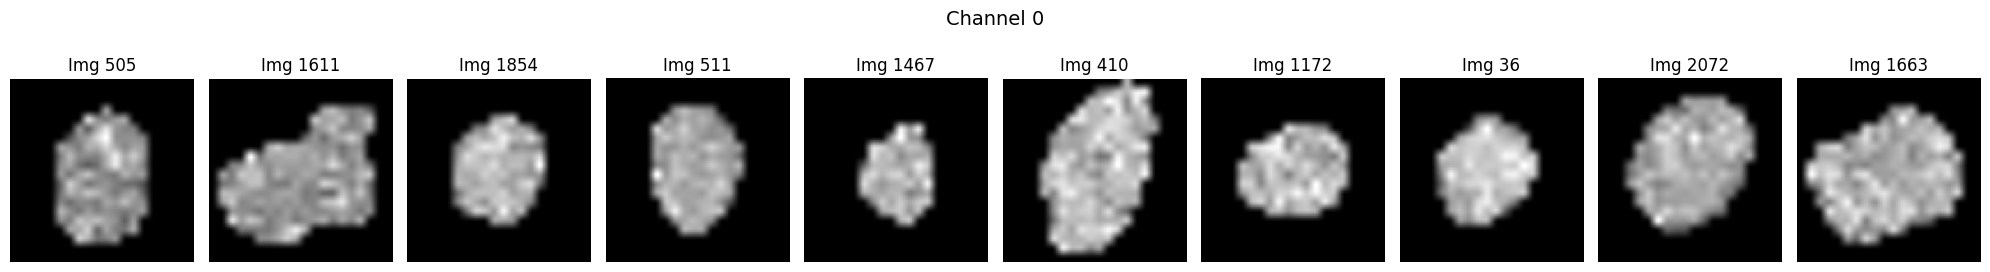

In [30]:
visualize_channels(dataset, num_channels=1)  # Visualize the first channel

# Adaptable VAE:

In [31]:
class AdaptableVAE(nn.Module):
    def __init__(self, img_channels: int, img_size: int, latent_dim: int = 2):
        super().__init__()

        self.img_channels = img_channels
        self.latent_dim = latent_dim
        self.img_size = img_size
        
        #----------------------#
        # Calculate total pixels and determine number of layers by linear interpolation
        total_pixels = img_size * img_size
        log_pixels = math.log2(total_pixels)

        # Interpolated layers between log2(400)=8.64 (2 layers) and log2(19600)=14.26 (4 layers)
        self.num_layers = int(round(2 + 0.356 * (log_pixels - 8.64)))
        #----------------------#

        # Define encoder channels dynamically
        base_channels = 32
        self.encoder_channels = [base_channels * (2 ** i) for i in range(self.num_layers)]
        self.final_size = img_size // (2 ** self.num_layers)
        self.flat_dim = self.encoder_channels[-1] * self.final_size * self.final_size

        # ---------------------
        # Encoder
        # ---------------------
        encoder_layers = []
        in_ch = img_channels
        for out_ch in self.encoder_channels:
            encoder_layers.extend([
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2)
            ])
            in_ch = out_ch
        self.encoder = nn.Sequential(*encoder_layers)

        # ---------------------
        # Latent space
        # ---------------------
        self.fc_mu = nn.Linear(self.flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_dim, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, self.flat_dim)

        # ---------------------
        # Decoder
        # ---------------------
        decoder_layers = []
        reversed_channels = list(reversed(self.encoder_channels))
        in_ch = reversed_channels[0]
        for out_ch in reversed_channels[1:]:
            decoder_layers.extend([
                nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1),
                nn.ReLU()
            ])
            in_ch = out_ch

        decoder_layers.extend([
            nn.ConvTranspose2d(in_ch, img_channels, kernel_size=4, stride=2, padding=1),
            nn.ReLU()
        ])
        self.decoder = nn.Sequential(*decoder_layers)

        self.final_upsample = nn.Upsample(size=(img_size, img_size), mode='bilinear', align_corners=True)
        
        decoder_layers = []
        reversed_channels = list(reversed(self.encoder_channels))
        in_ch = reversed_channels[0]
        current_size = self.final_size

        for out_ch in reversed_channels[1:]:
            next_size = current_size * 2
            expected = img_size // (2 ** (len(reversed_channels) - reversed_channels.index(out_ch)))
            output_padding = 1 if (next_size != expected) else 0

            decoder_layers.extend([
                nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1, output_padding=output_padding),
                nn.ReLU()
            ])
            in_ch = out_ch
            current_size = next_size

        # Final layer - handled separately because it projects back to pixel space AND the number of out channels is the number of image channels
        output_padding = 1 if (current_size * 2 < img_size) else 0
        decoder_layers.extend([
            nn.ConvTranspose2d(in_ch, img_channels, kernel_size=4, stride=2, padding=1, output_padding=output_padding),
            nn.ReLU()
        ])
        self.decoder = nn.Sequential(*decoder_layers)

        self.final_upsample = nn.Upsample(size=(img_size, img_size), mode='bilinear', align_corners=True)


    def encode(self, x):
        h = self.encoder(x)
        h_flat = h.view(-1, self.flat_dim)
        mu = self.fc_mu(h_flat)
        logvar = self.fc_logvar(h_flat)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h_flat = self.fc_decode(z)
        h = h_flat.view(-1, self.encoder_channels[-1], self.final_size, self.final_size)
        x_recon = self.decoder(h)
        return self.final_upsample(x_recon)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar
    
    def loss_function(self, recon_x, x, mu, logvar, beta=1.0):
        # Reconstruction loss (MSE for pixel-level similarity)
        reconstruction_loss = F.mse_loss(recon_x, x, reduction='sum')

        # KL Divergence
        kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

        return reconstruction_loss, beta * kl_divergence

In [32]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vae = AdaptableVAE(img_channels=1, img_size=80, latent_dim=2).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

#print(model)
#Additonal step:
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [44]:
summary(vae, input_size=(1, 1, 80, 80))

Layer (type:depth-idx)                   Output Shape              Param #
AdaptableVAE                             [1, 1, 80, 80]            --
├─Sequential: 1-1                        [1, 128, 10, 10]          --
│    └─Conv2d: 2-1                       [1, 32, 80, 80]           320
│    └─ReLU: 2-2                         [1, 32, 80, 80]           --
│    └─MaxPool2d: 2-3                    [1, 32, 40, 40]           --
│    └─Conv2d: 2-4                       [1, 64, 40, 40]           18,496
│    └─ReLU: 2-5                         [1, 64, 40, 40]           --
│    └─MaxPool2d: 2-6                    [1, 64, 20, 20]           --
│    └─Conv2d: 2-7                       [1, 128, 20, 20]          73,856
│    └─ReLU: 2-8                         [1, 128, 20, 20]          --
│    └─MaxPool2d: 2-9                    [1, 128, 10, 10]          --
├─Linear: 1-2                            [1, 2]                    25,602
├─Linear: 1-3                            [1, 2]                    25,60

In [33]:
# Print number of trainable parameters
print(f"Number of trainable parameters: {sum(p.numel() for p in vae.parameters() if p.requires_grad)}")

Number of trainable parameters: 346725


## Training:

In [35]:
# Initialize lists to store losses for plotting
total_losses = []
reconstruction_losses = []
kl_losses = []

num_epochs = 20
vae.train()

# Variable to store reconstructed images for the last epoch
final_reconstructed_images = []

for epoch in range(num_epochs):
    beta = 5  # KL weight
    epoch_total_loss = 0
    epoch_recon_loss = 0
    epoch_kl_loss = 0
    
    with tqdm(data_loader, unit="batch") as tepoch:
        for batch_idx, (images, _) in enumerate(tepoch):  # Updated unpacking to match CellDataset
            tepoch.set_description(f"Epoch {epoch+1}")

            images = images.to(device)
            
            # Print shape of images before input to the VAE
            #print(f"Batch {batch_idx}: Training Data Shape: {images.shape}")  # Expect (batch_size, 1, 20, 20)

            optimizer.zero_grad()  # Zero gradients
            
            recon_images, mu, logvar = vae(images)  # Forward pass
            
            # Print shape of latent space
            #print(f"Batch {batch_idx}: Latent Space Shape (mu): {mu.shape}")    # Expect (batch_size, latent_dim)
            #print(f"Batch {batch_idx}: Latent Space Shape (logvar): {logvar.shape}")  # Expect (batch_size, latent_dim)
            
            # Compute losses
            #recon_loss, kl_loss = vae.loss_function(recon_images, images, mu, logvar, beta)
            recon_loss, kl_loss = vae.loss_function(recon_images, images, mu, logvar)
            
            # Final loss = Only reconstruction loss (NO KL weight)
            total_loss = recon_loss + kl_loss 
            
            total_loss.backward()  # Backward pass
            
            torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=1)  # Gradient clipping
            
            optimizer.step()  # Optimizer step
            
            # Accumulate losses for the epoch
            epoch_total_loss += total_loss.item()
            epoch_recon_loss += recon_loss.item()
            epoch_kl_loss += kl_loss.item()
            
            # If it's the final epoch, collect reconstructed images
            if epoch == num_epochs - 1:
                final_reconstructed_images.append(recon_images.cpu())
            
            tepoch.set_postfix(
                recon_loss=recon_loss.item(),
                kl_loss=kl_loss.item(),
                total_loss=total_loss.item()
            )

    # Calculate average losses for the epoch
    avg_total_loss = epoch_total_loss / len(data_loader)
    avg_recon_loss = epoch_recon_loss / len(data_loader)
    avg_kl_loss = epoch_kl_loss / len(data_loader)

    # Store the average losses
    total_losses.append(avg_total_loss)
    reconstruction_losses.append(avg_recon_loss)
    kl_losses.append(avg_kl_loss)
    
    scheduler.step()
    print(f"Epoch {epoch+1}: Loss = {avg_total_loss / len(data_loader.dataset):.4f}")

# After training, concatenate all reconstructed images across epochs
final_reconstructed_images = torch.cat(final_reconstructed_images, dim=0)


Epoch 1:   0%|          | 0/69 [00:00<?, ?batch/s]

Epoch 1: 100%|██████████| 69/69 [01:05<00:00,  1.06batch/s, kl_loss=31.9, recon_loss=433, total_loss=465]        


Epoch 1: Loss = 0.9131


Epoch 2: 100%|██████████| 69/69 [00:52<00:00,  1.31batch/s, kl_loss=31.3, recon_loss=308, total_loss=339]       


Epoch 2: Loss = 0.7199


...

Epoch 18: Loss = 0.6407


Epoch 19: 100%|██████████| 69/69 [00:38<00:00,  1.78batch/s, kl_loss=33.3, recon_loss=310, total_loss=344]       


Epoch 19: Loss = 0.6408


Epoch 20: 100%|██████████| 69/69 [00:39<00:00,  1.76batch/s, kl_loss=31.8, recon_loss=280, total_loss=312]       


Epoch 20: Loss = 0.6379


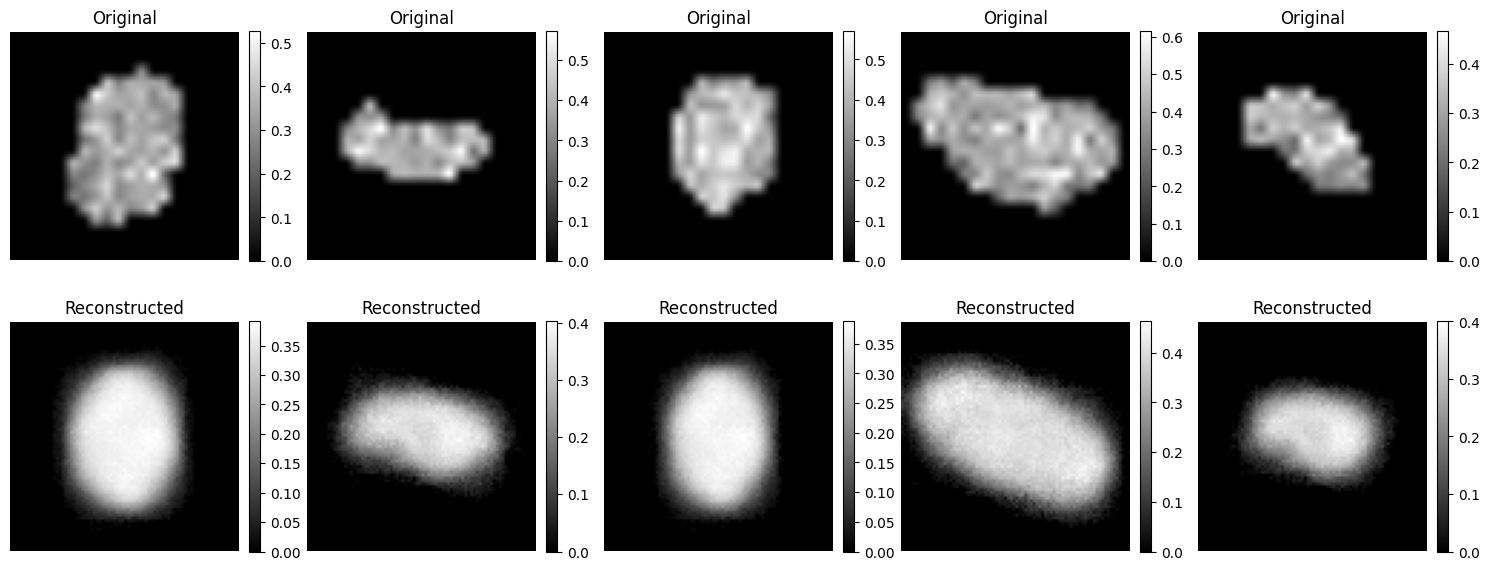

In [36]:
visualize_reconstructions(vae, data_loader, device)  # Visualize reconstructions

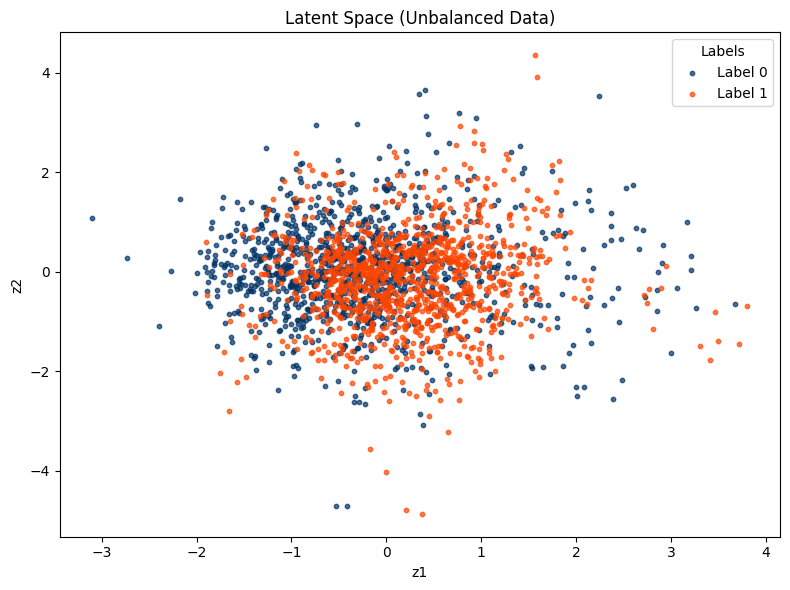

In [37]:
plot_full_latent_space(vae, data_loader, device)  # Plot latent space

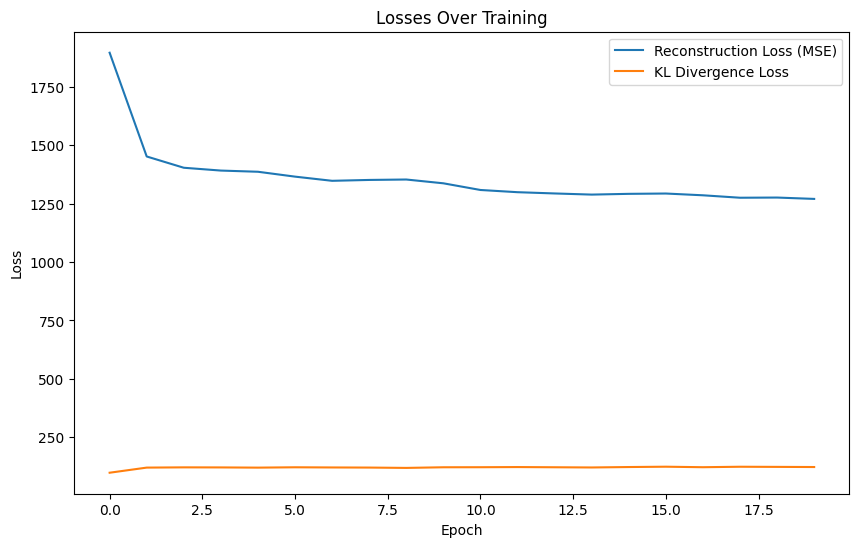

In [38]:
plt.figure(figsize=(10, 6))
#plt.plot(total_losses, label="Total Loss")
plt.plot(reconstruction_losses, label="Reconstruction Loss (MSE)")
plt.plot(kl_losses, label="KL Divergence Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Losses Over Training")
plt.legend()
plt.show()